# 02_predictive_modeling.ipynb — Part 4 extension

## Sections 6 and 7: SHAP and Fairness

This notebook extends `02_predictive_modeling.ipynb` with two appended sections
covering Session 1 Part 4 — Model Interpretation and Fairness.

| Section | Topic | Companion slide |
|---|---|---|
| 6.1 | SHAP TreeExplainer | S1.P4.6 |
| 6.2 | Global SHAP summary plot | S1.P4.7 |
| 6.3 | Local SHAP waterfall plot | S1.P4.8 |
| 7.1 | Bias spot-check on ABC Motor 2024 | S1.P4.13 |
| 7.2 | Demographic parity gap | S1.P4.13 |
| 7.3 | Equalised-odds gap | S1.P4.13 |

> **How to use this in the workshop notebook.** In the actual
> `02_predictive_modeling.ipynb`, Sections 1–5 already train the XGBoost
> claim-frequency model on ABC Motor 2024 (Part 3). Append Sections 6 and 7
> below directly after that work — they reuse the same `model`, `X_test`,
> `y_test`, and `df_test` objects in memory, so no rerunning is needed.
> The single "Recap from Part 3" cell that follows is included **only** to make
> this extension runnable standalone. Skip it when integrating.


---
## Recap from Part 3 *(skip when integrating)*

Reproduces the trained model and test set from `02_predictive_modeling.ipynb`
Part 3. The schema, persona names, and modelling choices match the workshop
spec in `00_personas_and_datasets.md`.

In [3]:
# --- Recap from Part 3 ---------------------------------------------------
# In the real notebook this block is replaced by the in-memory artefacts
# already produced by Sections 1-5. We rebuild a small synthetic version of
# ABC Motor 2024 here just so this extension runs standalone.

import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

rng = np.random.default_rng(42)
N = 60_000

# ABC Motor 2024 schema (subset used by the Part 3 frequency model)
gender = rng.choice(["M", "F"], size=N, p=[0.62, 0.38])
age = rng.integers(18, 75, size=N)
ncb_pct = rng.choice([0, 20, 25, 35, 45, 50, 55, 65], size=N,
                     p=[0.10, 0.10, 0.12, 0.13, 0.15, 0.20, 0.10, 0.10])
vehicle_age = rng.integers(0, 16, size=N)
engine_cc = rng.choice([800, 1000, 1200, 1500, 1800, 2000, 2500],
                       size=N, p=[0.05, 0.15, 0.30, 0.25, 0.15, 0.07, 0.03])
zone = rng.choice(["A", "B", "C", "D"], size=N, p=[0.30, 0.30, 0.25, 0.15])
prev_claims_3y = rng.choice([0, 1, 2, 3], size=N, p=[0.78, 0.16, 0.05, 0.01])

# True claim frequency — non-linear in age, ncb, vehicle age; gender effect small
log_freq = (
    -2.55
    + 0.018 * (age - 40) ** 2 / 100
    - 0.012 * ncb_pct
    + 0.04 * vehicle_age
    + 0.35 * prev_claims_3y
    + (zone == "A") * 0.18 + (zone == "D") * -0.10
    + (gender == "M") * 0.04
)
freq = np.exp(log_freq)
n_claims = rng.poisson(freq)

df = pd.DataFrame({
    "policy_id": [f"ABC-MOT-{i:06d}" for i in range(N)],
    "gender": gender, "age": age, "ncb_pct": ncb_pct,
    "vehicle_age": vehicle_age, "engine_cc": engine_cc,
    "zone": zone, "prev_claims_3y": prev_claims_3y,
    "n_claims": n_claims,
})

# Encode for XGBoost
features = ["gender_M", "age", "ncb_pct", "vehicle_age", "engine_cc",
            "zone_B", "zone_C", "zone_D", "prev_claims_3y"]
X = pd.DataFrame({
    "gender_M": (df.gender == "M").astype(int),
    "age": df.age, "ncb_pct": df.ncb_pct,
    "vehicle_age": df.vehicle_age, "engine_cc": df.engine_cc,
    "zone_B": (df.zone == "B").astype(int),
    "zone_C": (df.zone == "C").astype(int),
    "zone_D": (df.zone == "D").astype(int),
    "prev_claims_3y": df.prev_claims_3y,
})
y = df.n_claims

X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X, y, df, test_size=0.20, random_state=42)

model = xgb.XGBRegressor(
    objective="count:poisson",
    n_estimators=300, max_depth=4, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9,
    random_state=42, n_jobs=-1, verbosity=0,
)
model.fit(X_train, y_train)

print(f"Recap complete. Train: {len(X_train):,}  Test: {len(X_test):,}")
print(f"Test set portfolio frequency (observed): {y_test.mean():.4f}")
print(f"Test set portfolio frequency (predicted): {model.predict(X_test).mean():.4f}")


XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/rohanyashraj/Documents/GitHub/ifoa-workshop/.venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <B9202094-7D52-318C-99CF-7034B0E9F28D> /Users/rohanyashraj/Documents/GitHub/ifoa-workshop/.venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot

---
# Section 6 — SHAP: explaining the XGBoost frequency model

In Section 5 we accepted that the XGBoost model out-performs the GLM benchmark
on Gini and deviance. The next question — the question Priya gets from
Compliance, and the question Arjun gets from the Audit Committee — is
**why does it predict what it predicts?**

SHAP (SHapley Additive exPlanations) gives each feature its **fair share of
the prediction**, measured against the portfolio baseline. We use
`shap.TreeExplainer`, which computes exact SHAP values for tree-ensemble
models in low-polynomial time.

## 6.1 Instantiate `shap.TreeExplainer` *(slide S1.P4.6)*

In [2]:
import shap

# TreeExplainer is exact for XGBoost — no sampling, no surrogate model
explainer = shap.TreeExplainer(model)

# Compute SHAP values on the test set
shap_values = explainer.shap_values(X_test)

print(f"shap_values shape: {shap_values.shape}")
print(f"explainer.expected_value (baseline log-mean): {explainer.expected_value:.4f}")

# Mean absolute SHAP — the global feature ranking
mean_abs = np.abs(shap_values).mean(axis=0)
ranking = (pd.DataFrame({"feature": X_test.columns, "mean_abs_shap": mean_abs})
           .sort_values("mean_abs_shap", ascending=False)
           .reset_index(drop=True))
ranking


shap_values shape: (12000, 9)
explainer.expected_value (baseline log-mean): -2.4089


,feature,mean_abs_shap
0,ncb_pct,0.195755
1,prev_claims_3y,0.178196
2,vehicle_age,0.177623
3,age,0.082349
4,zone_B,0.059929
5,zone_C,0.050683
6,zone_D,0.040885
7,engine_cc,0.028746
8,gender_M,0.012629


## 6.2 Global SHAP summary — bee-swarm *(slide S1.P4.7)*

Each row is a feature; each dot is one policy. Horizontal position is the SHAP
value (push toward higher / lower predicted frequency). Colour is the feature
value (red = high, blue = low). What we want to see — and what an actuary
should sanity-check — is whether direction matches prior expectation:

- `prev_claims_3y`: red dots to the right (more prior claims → higher predicted frequency) ✓
- `ncb_pct`: red dots to the left (higher NCB → lower predicted frequency) ✓
- `age`: U-shape, with extremes pushing right ✓


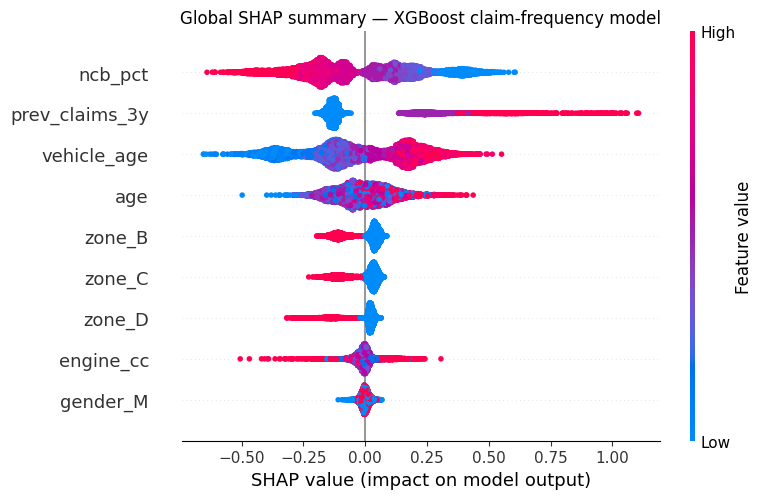

In [3]:
import matplotlib.pyplot as plt

# Global summary — bee-swarm of SHAP values across the test set
shap.summary_plot(shap_values, X_test, show=False, max_display=9)
plt.title("Global SHAP summary — XGBoost claim-frequency model", fontsize=12)
plt.tight_layout()
plt.show()


## 6.3 Local SHAP — one policy, one explanation *(slide S1.P4.8)*

Pick a single policy from the test set and walk through *its* prediction.
This is the artefact that goes into the regulator file: a per-policy
breakdown of why the model arrived at the price it did. Each bar in the
waterfall shows one feature's contribution, in the model's link-scale,
relative to the portfolio baseline.

In [4]:
# Pick one policy to explain — first row of the test set
idx = 0
policy_id = df_test.iloc[idx]["policy_id"]
features_row = X_test.iloc[idx]
predicted_freq = float(model.predict(X_test.iloc[[idx]])[0])

print(f"Selected policy:        {policy_id}")
print(f"Predicted frequency:    {predicted_freq:.4f}")
print(f"Portfolio baseline:     {model.predict(X_test).mean():.4f}\n")
print("Feature values for this policy:")
print(features_row.to_string())


Selected policy:        ABC-MOT-012628
Predicted frequency:    0.0976
Portfolio baseline:     0.0901

Feature values for this policy:
gender_M             1
age                 24
ncb_pct             20
vehicle_age         12
engine_cc         1200
zone_B               0
zone_C               1
zone_D               0
prev_claims_3y       0


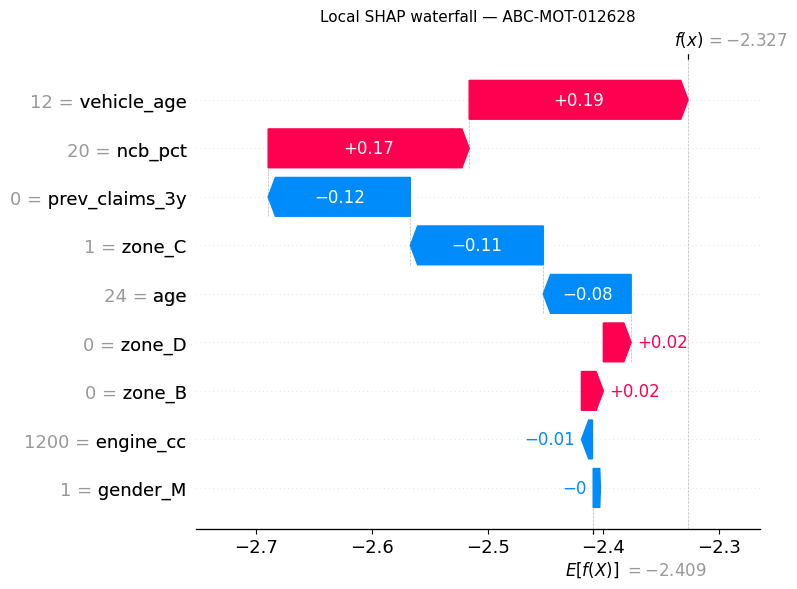

In [5]:
# Build a SHAP Explanation object so we can use the modern waterfall plot
explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx].values,
    feature_names=list(X_test.columns),
)

shap.plots.waterfall(explanation, max_display=9, show=False)
plt.title(f"Local SHAP waterfall — {policy_id}", fontsize=11)
plt.tight_layout()
plt.show()


**Reading the waterfall.** The bottom of the chart is the portfolio
baseline (`E[f(X)]`); the top is this policy's predicted log-frequency.
Each bar is one feature's contribution. Positive bars (red, pointing right)
push the prediction up; negative bars (blue, pointing left) push it down.

This is the explanation Priya hands to a customer disputing their renewal
quote, and the explanation Arjun puts in front of a regulator asking why
the model rated this policy the way it did.

---
# Section 7 — Fairness: bias spot-check on ABC Motor 2024 *(slide S1.P4.13)*

Interpretability tells us *why* the model predicts. Fairness tells us
*for whom* the model predicts well, and *for whom* it predicts badly.

The minimum bias spot-check, before any model ships, is:

1. Group the test set by every protected attribute (and every plausible proxy).
2. Compare **observed** outcome rates against **predicted** rates by group.
3. Compute a **demographic parity gap** (rate spread across groups).
4. Compute an **equalised-odds gap** on a binarised target.
5. Document both and walk them past Compliance.

We run that spot-check below on the gender × age cross-tab.

## 7.1 Observed vs predicted frequency by gender × age band

In [6]:
# Add predictions and an age band to the test frame
df_check = df_test.copy()
df_check["predicted"] = model.predict(X_test)

age_bins = [17, 25, 35, 50, 65, 100]
age_labels = ["18-25", "26-35", "36-50", "51-65", "66+"]
df_check["age_band"] = pd.cut(df_check["age"], bins=age_bins,
                              labels=age_labels, right=True)

bias_table = (df_check
              .groupby(["gender", "age_band"], observed=True)
              .agg(n=("policy_id", "count"),
                   observed=("n_claims", "mean"),
                   predicted=("predicted", "mean"))
              .reset_index())
bias_table["disparity"] = bias_table["predicted"] - bias_table["observed"]
bias_table["disparity_pct"] = 100 * bias_table["disparity"] / bias_table["observed"]
bias_table.round(4)


,gender,age_band,n,observed,predicted,disparity,disparity_pct
0,F,18-25,627,0.0813,0.0910,0.0096,11.8227
1,F,26-35,778,0.0887,0.0918,0.0031,3.5272
2,F,36-50,1176,0.0833,0.0800,-0.0033,-3.9572
3,F,51-65,1276,0.0846,0.0903,0.0056,6.6381
4,F,66+,748,0.0909,0.0953,0.0044,4.8287
5,M,18-25,1041,0.0865,0.0939,0.0074,8.5870
6,M,26-35,1276,0.0893,0.0870,-0.0023,-2.6229
7,M,36-50,1958,0.0848,0.0811,-0.0037,-4.3576
8,M,51-65,1973,0.0811,0.0936,0.0125,15.3786
9,M,66+,1147,0.0924,0.1043,0.0119,12.8825


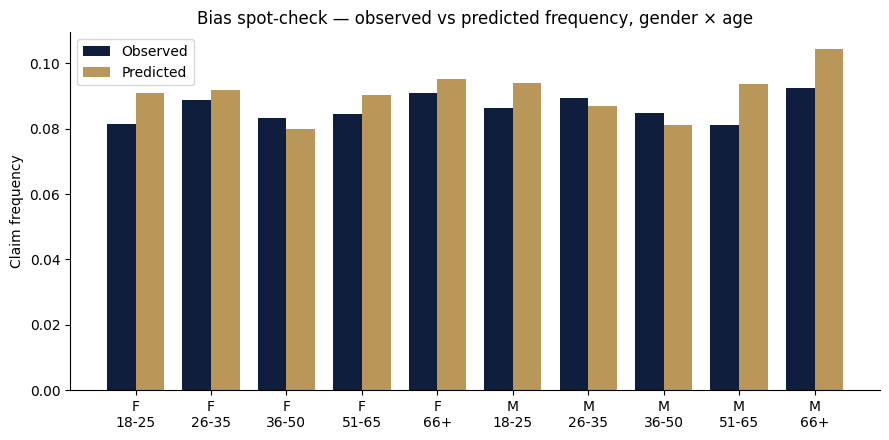

In [7]:
# Side-by-side bar chart — observed vs predicted by gender x age
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
groups = [(g, a) for g in ["F", "M"] for a in age_labels]
x = np.arange(len(groups))
width = 0.38

obs = [float(bias_table.query("gender == @g and age_band == @a")["observed"].iloc[0])
       for g, a in groups]
pred = [float(bias_table.query("gender == @g and age_band == @a")["predicted"].iloc[0])
        for g, a in groups]

ax.bar(x - width/2, obs, width, label="Observed", color="#0F1E3D")
ax.bar(x + width/2, pred, width, label="Predicted", color="#B89759")
ax.set_xticks(x)
ax.set_xticklabels([f"{g}\n{a}" for g, a in groups])
ax.set_ylabel("Claim frequency")
ax.set_title("Bias spot-check — observed vs predicted frequency, gender × age")
ax.legend()
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()


**What we're looking for in this chart.** Bars of equal height within each
gender×age group — predicted matches observed. Where they diverge, document the
size and direction. A consistent pattern of over-prediction or under-prediction
*for one gender* is the headline finding to escalate.

## 7.2 Demographic parity gap

**Demographic parity** asks whether the model's positive prediction rate is
the same across protected groups. Computed on a binarised target — for our
frequency model, a policy is "positive" if predicted frequency exceeds the
portfolio mean.

$$
\text{DP gap} = \max_g \Pr(\hat{Y}=1 \mid G=g) - \min_g \Pr(\hat{Y}=1 \mid G=g)
$$

A gap of 0 is perfect parity. The Hardt-Price-Srebro (2016) paper notes —
and Chouldechova (2017) makes formal — that you can almost never get 0 on
this *and* equalised odds *and* calibration at the same time. You pick.

In [8]:
# Binarise: positive prediction = predicted freq exceeds portfolio mean
threshold = df_check["predicted"].mean()
df_check["y_pred_bin"] = (df_check["predicted"] > threshold).astype(int)
df_check["y_true_bin"] = (df_check["n_claims"] > 0).astype(int)

print(f"Binarisation threshold (portfolio mean predicted freq): {threshold:.4f}\n")

dp_by_gender = df_check.groupby("gender")["y_pred_bin"].mean()
print("Positive prediction rate by gender:")
print(dp_by_gender.round(4).to_string())

dp_gap = dp_by_gender.max() - dp_by_gender.min()
print(f"\nDemographic parity gap (gender): {dp_gap:.4f}")


Binarisation threshold (portfolio mean predicted freq): 0.0901

Positive prediction rate by gender:
gender
F    0.3724
M    0.3805

Demographic parity gap (gender): 0.0081


## 7.3 Equalised-odds gap

**Equalised odds** asks whether the model has the same true-positive rate
*and* the same false-positive rate across protected groups. The gap is the
larger of the two component gaps.

$$
\text{EO gap} = \max\!\left(
   |\text{TPR}_{g_1} - \text{TPR}_{g_2}|,\
   |\text{FPR}_{g_1} - \text{FPR}_{g_2}|
\right)
$$

Where demographic parity sees only the *prediction*, equalised odds also
looks at the *truth* — so it penalises the model for being more accurate
on one group than the other.

In [9]:
def rates_by_group(df, group_col, y_true="y_true_bin", y_pred="y_pred_bin"):
    out = {}
    for g, sub in df.groupby(group_col):
        tp = ((sub[y_true] == 1) & (sub[y_pred] == 1)).sum()
        fn = ((sub[y_true] == 1) & (sub[y_pred] == 0)).sum()
        fp = ((sub[y_true] == 0) & (sub[y_pred] == 1)).sum()
        tn = ((sub[y_true] == 0) & (sub[y_pred] == 0)).sum()
        out[g] = {
            "TPR": tp / (tp + fn) if (tp + fn) else np.nan,
            "FPR": fp / (fp + tn) if (fp + tn) else np.nan,
        }
    return pd.DataFrame(out).T

eo = rates_by_group(df_check, "gender")
print("True-positive and false-positive rates by gender:")
print(eo.round(4).to_string())

tpr_gap = eo["TPR"].max() - eo["TPR"].min()
fpr_gap = eo["FPR"].max() - eo["FPR"].min()
eo_gap = max(tpr_gap, fpr_gap)

print(f"\nTPR gap: {tpr_gap:.4f}")
print(f"FPR gap: {fpr_gap:.4f}")
print(f"Equalised-odds gap (max of the two): {eo_gap:.4f}")


True-positive and false-positive rates by gender:
      TPR     FPR
F  0.5241  0.3590
M  0.5593  0.3643

TPR gap: 0.0353
FPR gap: 0.0053
Equalised-odds gap (max of the two): 0.0353


## 7.4 One-line summary — what goes in the model file

In [10]:
print(f"Demographic parity gap = {dp_gap:.4f}; equalised-odds gap = {eo_gap:.4f}")

Demographic parity gap = 0.0081; equalised-odds gap = 0.0353


---

### Reading the result

Both gaps are non-zero — they almost always are. The job at this point is
**not** to drive both to zero (the Chouldechova impossibility result on
slide S1.P4.10 says you can't), but to:

1. **Document** the gaps and the binarisation threshold used.
2. **Compare** them against the portfolio's prior model to confirm direction
   of travel.
3. **Decide** which fairness criterion is contractually or legally binding
   for this product, and report the gap on *that* metric in the model file.
4. **Re-run** this spot-check on every protected attribute available
   (and every proxy — postcode is the obvious next one) before the model
   ships.

That four-step sequence is the minimum viable fairness audit. Everything
else in the rest of Part 4 — the regulatory landscape, the professional
duty, the seven-question checklist — sits on top of having actually
produced these two numbers.
